In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
## opens sqlite database

conn = sqlite3.connect("./data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [10]:
def ships_over_frame(max_frames = 999999999):
  result = statement_to_df(f"""
    with combined as (select * from (select frame, 1 as val, owner from ships_created
    union all 
    select frame, -1 as val, owner from ships_destroyed)
    order by frame
  ),
  grouped as (select x, sum(y) over (order by x) as y from (select frame as x, sum(val) as y from combined group by frame))
  select * from grouped where x <= {max_frames} order by x;
  """)
  return result

def ships_grouped_over_frame(max_frames = 999999999):
  result = statement_to_df(f"""
    with combined as (select * from (select frame, 1 as val, owner from ships_created
    union all 
    select frame, -1 as val, owner from ships_destroyed)
    order by frame
  ),
  partitioned as (select owner, x, sum(y) over (partition by owner order by x) as y 
  from (select owner, frame as x, sum(val) as y from combined group by frame, owner)
  )

  select * from partitioned where x <= {max_frames} order by owner, x;
                           
""")
  return result




In [11]:
def plot_all(max_frames = 999999999):
    fig, axes = plt.subplots(4, 1, figsize=(16,12), dpi=160, sharex = True)
    ticks = statement_to_df(f"select tick as x, micros_elapsed / 1000.0 as y, game_id from game_ticks where tick <= {max_frames}")
    grouped_ticks = ticks.groupby("game_id")
    for name, group in grouped_ticks:
        axes[0].plot(group["x"], group["y"], label=name)
        axes[0].set_title("Server time to calculate tick")
        axes[0].set_ylabel("Server Tick (ms)")

    pings = statement_to_df(f"select tick as x, micros / 1000.0 as y from pings where tick <= {max_frames}")
    # ping_moving_avg = pings["y"].rolling(window=5).mean()
    axes[1].plot(pings["x"], pings["y"])
    axes[1].set_title("Client ping over time")
    axes[1].set_ylabel("Ping (ms)")

    ships = ships_over_frame(max_frames)
    axes[2].plot(ships["x"], ships["y"], label="Total Ships")
    axes[2].set_title("Total ships over time")
    axes[2].set_ylabel("Ships")

    for name, group in ships_grouped_over_frame(max_frames).groupby(["owner"]):
        #extend line to the end
        if len(group["x"]) > 1:
            axes[3].plot(group["x"], group["y"], label=name)
        else:
            axes[3].scatter(group["x"], group["y"], label=name)

    total_seconds = ticks["x"].max()*1/60
    axes[3].set_title("Ships per player over time")
    axes[3].set_xlabel(f"Frame ({total_seconds.round()} seconds)")
    #axes[3].legend()
    return [ticks, pings, ships]
# player_counts = statement_to_df("select tick as x, count as y from player_counts")


In [12]:
experiments_info = statement_to_df(f"""
                select id, number_of_servers, number_of_bots, number_of_servers * number_of_bots as total_bots from experiments
                """)
experiments_info

,id,number_of_servers,number_of_bots,total_bots
0,1,1,2,2
1,2,1,4,4
2,3,1,6,6
3,4,1,8,8
4,5,1,10,10
5,6,2,2,4
6,7,2,4,8
7,8,2,6,12
8,9,2,8,16
9,10,2,10,20


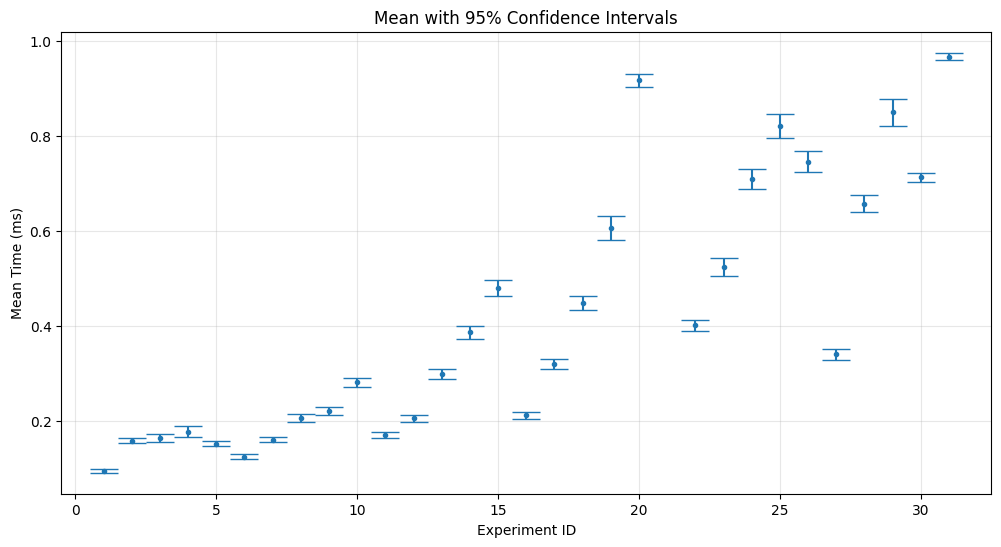

In [13]:
import scipy.stats as stats



df = statement_to_df(f"""
                select tick as x, micros_elapsed / 1000.0 as y, et.experiment_id
                from experiment_ticks et
                where et.tick > 200
                """)

example = df.groupby("experiment_id").get_group(10)
confidence = 0.95
data = example['y']
ci = stats.t.interval(confidence, len(data)-1, loc=data.mean(), scale=stats.sem(data))
ci

# Group by experiment and calculate stats
stats_df = df.groupby('experiment_id')['y'].agg(['mean', 'sem', 'count'])
stats_df['ci'] = stats_df.apply(
    lambda row: stats.t.ppf(0.975, row['count']-1) * row['sem'], 
    axis=1
)

plt.figure(figsize=(12, 6))
plt.errorbar(stats_df.index, stats_df['mean'], yerr=stats_df['ci'], 
             fmt='o', capsize=10, capthick=1, markersize=3)
plt.xlabel('Experiment ID')
plt.ylabel('Mean Time (ms)')
plt.title('Mean with 95% Confidence Intervals')
plt.grid(True, alpha=0.3)
plt.show()

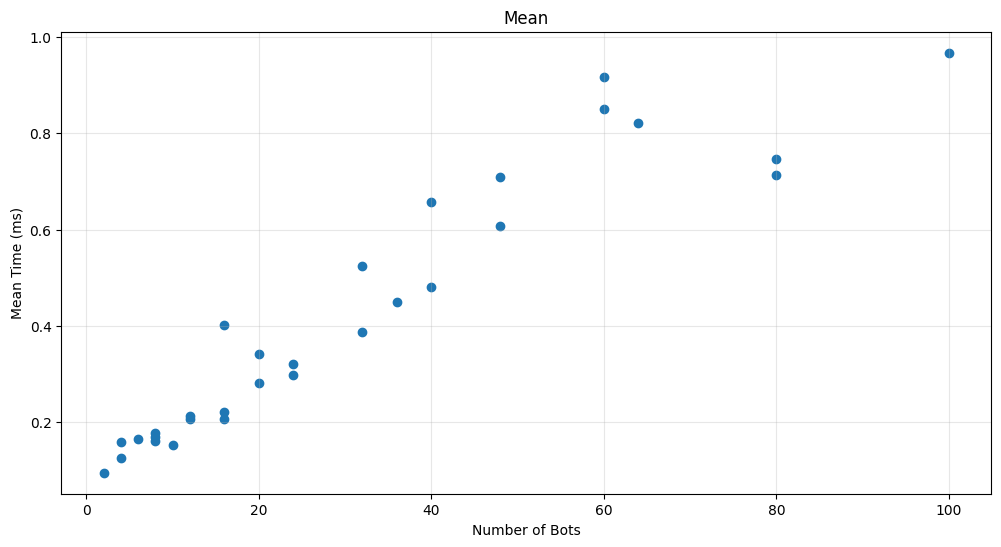

In [14]:
x_number_of_bots = experiments_info['total_bots']
plt.figure(figsize=(12, 6))
plt.scatter(x_number_of_bots, stats_df['mean'])
plt.xlabel('Number of Bots')
plt.ylabel('Mean Time (ms)')
plt.title('Mean')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression


# Merge the data
merged_df = stats_df.merge(experiments_info, left_index=True, right_on='id')

,id,number_of_servers,number_of_bots,total_bots
0,1,1,2,2
1,2,1,4,4
2,3,1,6,6
3,4,1,8,8
4,5,1,10,10
5,6,2,2,4
6,7,2,4,8
7,8,2,6,12
8,9,2,8,16
9,10,2,10,20
